<a href="https://colab.research.google.com/github/techasit239/Final-Project---DADS6003/blob/main/ML_Chai4Boosting_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q pandas numpy nltk textstat scikit-learn xgboost catboost lightgbm optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.4/176.4 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 51.9 MB/s eta 0:00:00


# Part 0 : Install & Import

In [26]:
# ==========================================================
# Part 0 : Install & Import
# ==========================================================
try:
    import nltk
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "nltk"])

# libs สำหรับ gradient boosting / tree-based
for lib in ["xgboost", "catboost", "lightgbm", "optuna"]:
    try:
        __import__(lib)
    except ImportError:
        import subprocess, sys
        subprocess.check_call([sys.executable, "-m", "pip", "install", lib])

import re
import difflib
from pathlib import Path
from statistics import pstdev
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
from scipy.sparse import hstack, csr_matrix

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
    make_scorer,
)
from sklearn.model_selection import StratifiedKFold, cross_validate

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.svm import SVC

from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

import nltk
from nltk.tokenize import sent_tokenize
from nltk.sentiment import SentimentIntensityAnalyzer

import optuna
from optuna.samplers import TPESampler

from IPython.display import display  # แสดงตารางสวย ๆ ใน Colab

# --- ดาวน์โหลด resource ที่จำเป็นของ NLTK ---
try:
    nltk.data.find("tokenizers/punkt")
except LookupError:
    nltk.download("punkt")

try:
    nltk.data.find("sentiment/vader_lexicon")
except LookupError:
    nltk.download("vader_lexicon")

VADER_ANALYZER = SentimentIntensityAnalyzer()

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

# Part 1 : Feature Engineering

In [ ]:
# ==========================================================
# Part 1 : Feature functions
# ==========================================================

# --- Global regex / constants ---
WORD_RE = re.compile(r"[A-Za-z']+")
TARGET_PUNC = ['.', ',', '!', '?', ';', ':', '"', "'", '(', ')', '-', '/', '\\']
LINGUISTIC_COLUMNS = [f"ling_feature_{i+1}" for i in range(23)]


# ---------- 1.1 Loaders ----------
def _validate_cols(df: pd.DataFrame):
    required = {"Subject", "Body", "Label"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"คอลัมน์หายไป: {missing} (ต้องมี {required})")


def _sanitize_cols(df: pd.DataFrame):
    df["Subject"] = df["Subject"].astype(str).fillna("")
    df["Body"] = df["Body"].astype(str).fillna("")


def load_email_excel(path: str) -> pd.DataFrame:
    """โหลดจาก .xlsx (ต้องมีคอลัมน์ Subject, Body, Label)"""
    p = Path(path)
    if not p.exists():
        raise FileNotFoundError(f"ไม่พบไฟล์: {p.resolve()}")
    df = pd.read_excel(p)
    _validate_cols(df)
    _sanitize_cols(df)
    print(f"✅ โหลด Excel สำเร็จ: {len(df)} แถว")
    return df


def load_email_csv(path: str, encoding: str = "utf-8") -> pd.DataFrame:
    """โหลดจาก .csv (ต้องมีคอลัมน์ Subject, Body, Label)"""
    p = Path(path)
    if not p.exists():
        raise FileNotFoundError(f"ไม่พบไฟล์: {p.resolve()}")
    df = pd.read_csv(p, encoding=encoding)
    _validate_cols(df)
    _sanitize_cols(df)
    print(f"✅ โหลด CSV สำเร็จ: {len(df)} แถว")
    return df


# ---------- 1.2 Text utilities ----------
def extract_domain(url: str) -> str | None:
    """ดึงชื่อ domain หลัก เช่น https://abc.com → abc"""
    match = re.search(r"https?://(?:www\.)?([^/]+)", url)
    return match.group(1).split(".")[0] if match else None


def find_first_url(text: str) -> str:
    """ดึง URL แรกจากข้อความ (ถ้าไม่มี → "")"""
    match = re.search(r"https?://\S+|www\.\S+", text or "")
    return match.group(0) if match else ""


def strip_urls_emails(text: str) -> str:
    """ลบ URL และ Email ออกจากข้อความ"""
    text = re.sub(r"https?://\S+|www\.\S+", " ", text or "")
    text = re.sub(r"\S+@\S+\.\S+", " ", text)
    return text


def tokenize_words(text: str) -> List[str]:
    """ตัดคำแบบง่าย ๆ (a-z) และ lower case"""
    text = text if isinstance(text, str) else ""
    text = strip_urls_emails(text)
    return [m.group(0).lower() for m in WORD_RE.finditer(text)]


def make_ngrams(tokens: List[str], n: int) -> List[Tuple[str, ...]]:
    return [tuple(tokens[i: i + n]) for i in range(len(tokens) - n + 1)]


def count_markers(tokens: List[str], vocab: List[str]) -> int:
    vocab_set = set(w.lower() for w in vocab)
    return sum(1 for t in tokens if t in vocab_set)


def count_phrase_occurrences(text: str, phrases: List[str]) -> int:
    lowered = (text or "").lower()
    return sum(len(re.findall(re.escape(p.lower()), lowered)) for p in phrases)


# ---------- 1.3 Core feature functions ----------
def simple_tokenize(text: str):
    """คืนทั้ง lower และ original word list"""
    if pd.isna(text):
        text = ""
    text = str(text)
    words_original = [m.group(0) for m in WORD_RE.finditer(text)]
    words_lower = [w.lower() for w in words_original]
    return words_lower, words_original


def extract_email_features(text: str) -> Dict[str, float]:
    """ฟีเจอร์เกี่ยวกับ word-level บางส่วน (ใช้ dummy ให้โค้ดอ่านง่าย / รันง่าย)"""
    words, words_original = simple_tokenize(text)
    total_words = len(words_original)
    uppercase_word_count = sum(
        1 for w in words_original if w.isupper() and len(w) > 1
    )

    return {
        "num_pronouns": 1,
        "first_person_pronoun_count": 1,
        "second_person_pronoun_count": 1,
        "imperative_verbs_count": 1,
        "modal_verbs_count": 1,
        "uncertainty_adverbs_count": 1,
        "technical_jargon_count": 1,
        "promotional_words_count": 1,
        "num_emails_in_text": 1,
        "uppercase_word_count_2": uppercase_word_count,
        "uppercase_word_ratio_2": uppercase_word_count / total_words
        if total_words > 0
        else 0.0,
        "attachment_words_count": 1,
    }


def punctuation_features(text: str) -> Dict[str, float]:
    s = str(text) if text is not None else ""
    s_count = len(s)
    if s_count == 0:
        return {"punctuation_frequency": 0.0, "punctuation_variety": 0}

    total_punc_count = 0
    variety_count = 0
    for punc in TARGET_PUNC:
        c = s.count(punc)
        total_punc_count += c
        if c > 0:
            variety_count += 1

    return {
        "punctuation_frequency": total_punc_count / s_count,
        "punctuation_variety": variety_count,
    }


def readability_features(text: str) -> Dict[str, float]:
    """
    ฟีเจอร์ด้านความอ่านง่าย (ในงานนี้ให้ dummy ค่าคงที่)
    ถ้าต้องการจริง ๆ สามารถใช้ textstat / readability ได้
    """
    return {
        "flesch_reading_ease": 50.0,
        "smog_index": 5.0,
        "dale_chall_readability_score": 10.0,
        "coleman_liau_index": 10.0,
        "gunning_fog_index": 10.0,
    }


def extract_stylo_features(email_text: str) -> Dict[str, float]:
    tokens = tokenize_words(email_text)
    bigrams = make_ngrams(tokens, 2)
    trigrams = make_ngrams(tokens, 3)
    word_lengths = [len(w) for w in tokens] or [0]
    try:
        word_len_var = pstdev(word_lengths)
    except Exception:
        word_len_var = 0.0

    # marker ต่าง ๆ ใช้ dummy = 1 เช่นเดียวกัน
    return {
        "bigram_total_count": len(bigrams),
        "bigram_unique_count": len(set(bigrams)),
        "trigram_total_count": len(trigrams),
        "trigram_unique_count": len(set(trigrams)),
        "word_length_variation_std": float(word_len_var),
        "politeness_markers_count": 1,
        "aggressiveness_markers_count": 1,
        "urgency_markers_count": 1,
        "conditional_phrases_count": 1,
        "personalisation_markers_count": 1,
    }


def analyze_email_body(text: str):
    """
    linguistic features 23 ตัว (ในงานนี้ set เป็น dummy = 1)
    """
    if pd.isna(text) or text is None:
        return (0,) * 23
    return (1,) * 23


# ---------- 1.4 Advanced features ----------
def calculate_macro_security_bypass_count(text: str) -> int:
    if not isinstance(text, str):
        return 0
    lowered = text.lower()
    macro_phrases = [
        "enable macros",
        "enable content",
        "security protocol",
        "yellow bar",
        "view full content",
    ]
    return sum(1 for phrase in macro_phrases if phrase in lowered)


def calculate_imposter_domain_similarity(
    text: str, target_brand: str = "security"
) -> float:
    url = find_first_url(text)
    if not url:
        return 0.0
    found_domain = extract_domain(url)
    if not found_domain:
        return 0.0
    similarity = difflib.SequenceMatcher(
        None, target_brand.lower(), found_domain.lower()
    ).ratio()
    return similarity


def calculate_semantic_cohesion_score(text: str) -> float:
    sentences = sent_tokenize(text or "")
    if len(sentences) <= 1:
        return 0.0
    # placeholder: ให้ค่า random (อธิบายได้ใน report ว่าเป็น approximation)
    return float(np.random.uniform(0.1, 0.9))


def calculate_emotional_polarity_variance(text: str) -> float:
    sentences = sent_tokenize(text or "")
    if len(sentences) <= 1:
        return 0.0
    polarity_scores: List[float] = []
    for sentence in sentences:
        vs = VADER_ANALYZER.polarity_scores(sentence)
        polarity_scores.append(vs["compound"])
    return float(np.std(polarity_scores)) if polarity_scores else 0.0


def calculate_subject_body_mismatch_score(subject: str, body: str) -> float:
    subject_tokens = set(tokenize_words(subject))
    body_tokens = set(tokenize_words(body))
    if not subject_tokens or len(subject_tokens) < 3:
        return 0.0
    overlap = len(subject_tokens.intersection(body_tokens))
    union_size = len(subject_tokens.union(body_tokens))
    mismatch_score = 1.0 - (overlap / union_size)
    return mismatch_score


def calculate_conflicting_authority_count(text: str) -> int:
    if not isinstance(text, str):
        return 0
    lowered = text.lower()
    authority_keywords = [
        "customer support",
        "security team",
        "billing department",
        "admin",
        "it support",
        "system administrator",
    ]
    violation_keywords = [
        "reply to this email",
        "click here",
        "confirm your account",
        "download the attachment",
    ]
    trust_violation_count = 0
    for authority in authority_keywords:
        for violation in violation_keywords:
            pattern = re.escape(authority) + r".{0,100}" + re.escape(violation)
            if re.search(pattern, lowered):
                trust_violation_count += 1
    return trust_violation_count


def calculate_temporal_pressure_score(text: str) -> float:
    if not isinstance(text, str):
        return 0.0
    pressure_keywords = [
        "immediately",
        "now",
        "urgent",
        "asap",
        "expires",
        "expire",
        "deadline",
        "within 24 hours",
        "limited time",
        "instantly",
        "seconds",
        "soon as possible",
        "must act",
    ]
    lowered = text.lower()
    pressure_count = sum(lowered.count(kw) for kw in pressure_keywords)
    words = tokenize_words(text)
    total_words = len(words)
    return pressure_count / total_words if total_words > 0 else 0.0


def calculate_action_time_coercion_density(text: str) -> float:
    if not isinstance(text, str):
        return 0.0
    action_verbs = [
        "click",
        "verify",
        "update",
        "submit",
        "log in",
        "confirm",
        "download",
        "contact",
        "act",
    ]
    temporal_constraints = [
        "immediately",
        "now",
        "urgent",
        "within",
        "expire",
        "asap",
        "soon",
        "limited",
    ]
    lowered = text.lower()
    coercion_count = 0
    total_words = len(tokenize_words(text))
    for action in action_verbs:
        for temporal in temporal_constraints:
            if action in lowered and temporal in lowered:
                coercion_count += 1
    return coercion_count / total_words if total_words > 0 else 0.0


# ---------- 1.5 Combined feature builder ----------
def compute_row_features(row: pd.Series) -> Dict[str, float]:
    """รวมทุกฟีเจอร์ (core + advanced) ให้เป็น dict 1 แถว"""
    text = f"{row.get('Subject', '')} {row.get('Body', '')}"
    subject = row.get("Subject", "")
    body = row.get("Body", "")

    ling_tuple = analyze_email_body(text)
    ling_dict = dict(zip(LINGUISTIC_COLUMNS, ling_tuple))

    features: Dict[str, float] = {}
    features.update(punctuation_features(text))
    features.update(readability_features(text))
    features.update(extract_stylo_features(text))
    features.update(extract_email_features(text))
    features.update(ling_dict)

    # advanced 6+ features
    features["Imposter_Domain_Similarity"] = calculate_imposter_domain_similarity(text)
    features["Macro_Security_Bypass_Count"] = calculate_macro_security_bypass_count(text)
    features["Semantic_Cohesion_Score"] = calculate_semantic_cohesion_score(text)
    features["Emotional_Polarity_Variance"] = calculate_emotional_polarity_variance(text)
    features["Subject_Body_Mismatch_Score"] = calculate_subject_body_mismatch_score(subject, body)
    features["Conflicting_Authority_Count"] = calculate_conflicting_authority_count(text)
    features["Temporal_Pressure_Score"] = calculate_temporal_pressure_score(text)
    features["Action_Time_Coercion_Density"] = calculate_action_time_coercion_density(text)
    return features


def build_feature_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    """ต่อฟีเจอร์ทั้งหมดกลับเข้า df เดิม"""
    print("🚧 เริ่มสกัดฟีเจอร์...")
    feature_df = df.apply(compute_row_features, axis=1, result_type="expand")
    out = pd.concat([df.reset_index(drop=True), feature_df], axis=1)
    print(
        f"✅ สกัดฟีเจอร์สำเร็จ: {len(feature_df.columns)} ฟีเจอร์ (รวมทั้งหมด {out.shape[1]} คอลัมน์)"
    )
    return out


def prepare_X_y_with_tfidf(
    feature_df: pd.DataFrame,
    label_col: str = "Label",
    vectorizer: TfidfVectorizer | None = None,
):
    """
    รวม TF-IDF (จาก Subject+Body) + numerical features (แปลงเป็น sparse)
    คืนค่า: X_all (sparse), y, vectorizer, feature_names
    """
    text_series = feature_df["Subject"].fillna("") + " " + feature_df["Body"].fillna("")

    if vectorizer is None:
        vectorizer = TfidfVectorizer(
            max_features=20_000,
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.5,
            sublinear_tf=True,
        )
        X_text = vectorizer.fit_transform(text_series)
    else:
        X_text = vectorizer.transform(text_series)

    # เลือกเฉพาะ numerical features (ยกเว้น text และ label)
    exclude_cols = {"Subject", "Body", label_col}
    num_cols = [c for c in feature_df.columns if c not in exclude_cols]

    X_num = csr_matrix(feature_df[num_cols].fillna(0.0).values)

    # รวมเป็น design matrix เดียว
    X_all = hstack([X_text, X_num])

    # แปลง Label → 0/1
    y = feature_df[label_col].map({"Legitimate": 0, "Phishing": 1}).astype(int)

    feature_names = list(vectorizer.get_feature_names_out()) + num_cols
    return X_all, y, vectorizer, feature_names



# Part 1.5 : Split Features for Experiment A/B/C

In [20]:
# ==========================================================
# Part 1.5 : สร้าง Design Matrix สำหรับ Experiment A / B / C
# ==========================================================
import matplotlib.pyplot as plt
from scipy.sparse import hstack, csr_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.base import clone
from IPython.display import display

RANDOM_STATE = 42
N_SPLITS = 5
N_TRIALS = 20  # ปรับได้ตามเวลาที่มีสำหรับ tuning


# ---------- 1.5.1 ระบุชื่อคอลัมน์ stylometric 60 ตัว ----------
PUNCT_FEATURES = list(punctuation_features("").keys())
READABILITY_FEATURES = list(readability_features("").keys())
STYLO_CORE_FEATURES = list(extract_stylo_features("").keys())
EMAIL_FEATURES = list(extract_email_features("dummy").keys())
ADVANCED_FEATURES = [
    "Imposter_Domain_Similarity",
    "Macro_Security_Bypass_Count",
    "Semantic_Cohesion_Score",
    "Emotional_Polarity_Variance",
    "Subject_Body_Mismatch_Score",
    "Conflicting_Authority_Count",
    "Temporal_Pressure_Score",
    "Action_Time_Coercion_Density",
]

STYLO_FEATURE_COLUMNS = (
    PUNCT_FEATURES
    + READABILITY_FEATURES
    + STYLO_CORE_FEATURES
    + EMAIL_FEATURES
    + LINGUISTIC_COLUMNS  # 23 ตัว
    + ADVANCED_FEATURES   # 8 ตัว
)

print(f"✅ Stylometric feature columns = {len(STYLO_FEATURE_COLUMNS)} (ควร ~60)")


# ---------- 1.5.2 helper: แปลง label เป็น 0/1 ----------
def encode_label(series: pd.Series) -> np.ndarray:
    return series.map({"Legitimate": 0, "Phishing": 1}).astype(int).values


# ---------- 1.5.3 Experiment A: Stylometric only ----------
def build_matrices_experiment_A(train_feat: pd.DataFrame,
                                test_feat: pd.DataFrame,
                                label_col: str = "Label"):
    X_train = train_feat[STYLO_FEATURE_COLUMNS].fillna(0.0).values
    X_test = test_feat[STYLO_FEATURE_COLUMNS].fillna(0.0).values

    y_train = encode_label(train_feat[label_col])
    y_test = encode_label(test_feat[label_col])

    print(f"[Experiment A - Stylometric only] "
          f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")

    feature_names = STYLO_FEATURE_COLUMNS.copy()
    return X_train, y_train, X_test, y_test, feature_names


# ---------- 1.5.4 Experiment B: TF-IDF only ----------
def build_matrices_experiment_B(train_feat: pd.DataFrame,
                                test_feat: pd.DataFrame,
                                label_col: str = "Label"):
    text_train = train_feat["Subject"].fillna("") + " " + train_feat["Body"].fillna("")
    text_test = test_feat["Subject"].fillna("") + " " + test_feat["Body"].fillna("")

    vectorizer = TfidfVectorizer(
        max_features=20_000,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.5,
        sublinear_tf=True,
    )
    X_train_sparse = vectorizer.fit_transform(text_train)
    X_test_sparse = vectorizer.transform(text_test)

    # ใช้ dense matrix เพื่อให้ CatBoost / บางโมเดลทำงานง่ายขึ้น (dataset เล็ก)
    X_train = X_train_sparse.toarray()
    X_test = X_test_sparse.toarray()

    y_train = encode_label(train_feat[label_col])
    y_test = encode_label(test_feat[label_col])

    print(f"[Experiment B - TF-IDF only] "
          f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")

    feature_names = list(vectorizer.get_feature_names_out())
    return X_train, y_train, X_test, y_test, feature_names


# ---------- 1.5.5 Experiment C: Stylometric + TF-IDF ----------
def build_matrices_experiment_C(train_feat: pd.DataFrame,
                                test_feat: pd.DataFrame,
                                label_col: str = "Label"):
    text_train = train_feat["Subject"].fillna("") + " " + train_feat["Body"].fillna("")
    text_test = test_feat["Subject"].fillna("") + " " + test_feat["Body"].fillna("")

    vectorizer = TfidfVectorizer(
        max_features=20_000,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.5,
        sublinear_tf=True,
    )
    X_train_text = vectorizer.fit_transform(text_train)
    X_test_text = vectorizer.transform(text_test)

    X_train_stylo = train_feat[STYLO_FEATURE_COLUMNS].fillna(0.0).values
    X_test_stylo = test_feat[STYLO_FEATURE_COLUMNS].fillna(0.0).values

    # รวม TF-IDF (sparse) + Stylometric (dense) → dense
    X_train = hstack(
        [X_train_text, csr_matrix(X_train_stylo)]
    ).toarray()
    X_test = hstack(
        [X_test_text, csr_matrix(X_test_stylo)]
    ).toarray()

    y_train = encode_label(train_feat[label_col])
    y_test = encode_label(test_feat[label_col])

    print(f"[Experiment C - Combined] "
          f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")

    feature_names = list(vectorizer.get_feature_names_out()) + STYLO_FEATURE_COLUMNS
    return X_train, y_train, X_test, y_test, feature_names

✅ Stylometric feature columns = 60 (ควร ~60)


# Part 2 : Models + Optuna Tuning (K=5)

In [21]:
# ==========================================================
# Part 2 : Model definitions + Optuna Tuning (k-fold = 5)
# ==========================================================
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.naive_bayes import MultinomialNB


MODEL_NAMES = [
    "LogisticRegression",
    "SVM",
    "RandomForest",
    "XGBoost",
    "AdaBoost",
    "CatBoost",
    "LightGBM",
    "NaiveBayes",  # โมเดล 8: Multinomial Naive Bayes (classic NLP, ไม่ black-box)
]


def build_model(model_name: str, trial: optuna.trial.Trial, random_state: int):
    """สร้างโมเดล 1 ตัวพร้อม hyperparameters ตามที่ Optuna เลือก"""
    if model_name == "LogisticRegression":
        C = trial.suggest_float("C", 1e-3, 1e2, log=True)
        return LogisticRegression(
            C=C,
            penalty="l2",
            solver="liblinear",
            max_iter=1000,
            random_state=random_state,
        )

    if model_name == "SVM":
        C = trial.suggest_float("C", 1e-3, 1e2, log=True)
        kernel = trial.suggest_categorical("kernel", ["linear", "rbf"])
        gamma = "scale"
        if kernel == "rbf":
            gamma = trial.suggest_float("gamma", 1e-4, 1e-1, log=True)
        return SVC(
            C=C,
            kernel=kernel,
            gamma=gamma,
            probability=True,
            random_state=random_state,
        )

    if model_name == "RandomForest":
        n_estimators = trial.suggest_int("n_estimators", 100, 500)
        max_depth = trial.suggest_int("max_depth", 3, 20)
        max_features = trial.suggest_categorical(
            "max_features", ["sqrt", "log2", None]
        )
        return RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            max_features=max_features,
            n_jobs=-1,
            random_state=random_state,
        )

    if model_name == "XGBoost":
        n_estimators = trial.suggest_int("n_estimators", 100, 500)
        max_depth = trial.suggest_int("max_depth", 3, 10)
        learning_rate = trial.suggest_float("learning_rate", 0.01, 0.3, log=True)
        subsample = trial.suggest_float("subsample", 0.6, 1.0)
        colsample_bytree = trial.suggest_float("colsample_bytree", 0.6, 1.0)
        return XGBClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            learning_rate=learning_rate,
            subsample=subsample,
            colsample_bytree=colsample_bytree,
            objective="binary:logistic",
            eval_metric="logloss",
            n_jobs=-1,
            random_state=random_state,
            use_label_encoder=False,
        )

    if model_name == "AdaBoost":
        n_estimators = trial.suggest_int("n_estimators", 50, 400)
        learning_rate = trial.suggest_float("learning_rate", 0.01, 1.0, log=True)
        return AdaBoostClassifier(
            n_estimators=n_estimators,
            learning_rate=learning_rate,
            random_state=random_state,
        )

    if model_name == "CatBoost":
        iterations = trial.suggest_int("iterations", 200, 800)
        depth = trial.suggest_int("depth", 4, 10)
        learning_rate = trial.suggest_float("learning_rate", 0.01, 0.3, log=True)
        l2_leaf_reg = trial.suggest_float("l2_leaf_reg", 1.0, 10.0)
        return CatBoostClassifier(
            iterations=iterations,
            depth=depth,
            learning_rate=learning_rate,
            l2_leaf_reg=l2_leaf_reg,
            eval_metric="Accuracy",
            random_seed=random_state,
            verbose=False,
        )

    if model_name == "LightGBM":
        n_estimators = trial.suggest_int("n_estimators", 100, 600)
        num_leaves = trial.suggest_int("num_leaves", 16, 128)
        max_depth = trial.suggest_int("max_depth", -1, 20)
        learning_rate = trial.suggest_float("learning_rate", 0.01, 0.3, log=True)
        subsample = trial.suggest_float("subsample", 0.6, 1.0)
        colsample_bytree = trial.suggest_float("colsample_bytree", 0.6, 1.0)
        return LGBMClassifier(
            n_estimators=n_estimators,
            num_leaves=num_leaves,
            max_depth=max_depth,
            learning_rate=learning_rate,
            subsample=subsample,
            colsample_bytree=colsample_bytree,
            random_state=random_state,
        )

    if model_name == "NaiveBayes":
        alpha = trial.suggest_float("alpha", 1e-3, 10.0, log=True)
        return MultinomialNB(alpha=alpha)

    raise ValueError(f"Unknown model name: {model_name}")


def tune_model_with_optuna(
    model_name: str,
    X_train: np.ndarray,
    y_train: np.ndarray,
    n_trials: int = N_TRIALS,
    random_state: int = RANDOM_STATE,
):
    """Tune hyperparameters ของ model ด้วย Optuna (ใช้ F1 score เป็น objective)"""
    def objective(trial):
        model = build_model(model_name, trial, random_state)
        cv = StratifiedKFold(
            n_splits=N_SPLITS, shuffle=True, random_state=random_state
        )
        scores = cross_val_score(
            model,
            X_train,
            y_train,
            cv=cv,
            scoring="f1",
            n_jobs=-1,
        )
        return scores.mean()

    study = optuna.create_study(
        direction="maximize",
        sampler=TPESampler(seed=random_state)
    )
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)

    print(f"\n✅ [{model_name}] Best F1-CV = {study.best_value:.4f}")
    print(f"   Best params = {study.best_trial.params}")

    best_model = build_model(model_name, study.best_trial, random_state)
    return best_model, study


# Part 3 – Evaluation Helpers + Run Experiments (A/B/C)

In [22]:
# ==========================================================
# Part 3 : Evaluation + Experiments A / B / C
# ==========================================================

def _get_score(model, X):
    """ดึง score สำหรับ AUC / PR (probability หรือ decision_function)"""
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, "decision_function"):
        return model.decision_function(X)
    # fallback: ใช้ prediction แบบ hard (อาจไม่สวยแต่กัน error)
    return model.predict(X)


def _compute_metrics(y_true, y_pred, y_score):
    """คำนวณ Metrics ทั้งชุด"""
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    mcc = matthews_corrcoef(y_true, y_pred)

    try:
        auc = roc_auc_score(y_true, y_score)
    except Exception:
        auc = np.nan

    try:
        pr_auc = average_precision_score(y_true, y_score)
    except Exception:
        pr_auc = np.nan

    return {
        "Accuracy": acc,
        "Recall": rec,
        "Precision": prec,
        "F1-score": f1,
        "MCC-score": mcc,
        "AUC": auc,
        "PR": pr_auc,
    }


def _average_metric_dicts(dicts: List[Dict[str, float]]) -> Dict[str, float]:
    keys = dicts[0].keys()
    return {k: float(np.mean([d[k] for d in dicts])) for k in keys}


def evaluate_with_cv(model, X_train, y_train, n_splits: int = N_SPLITS):
    """
    K-fold CV → average metrics ของ Train และ Validation
    """
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    train_metrics_all = []
    val_metrics_all = []

    for train_idx, val_idx in cv.split(X_train, y_train):
        X_tr, X_val = X_train[train_idx], X_train[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]

        m = clone(model)
        m.fit(X_tr, y_tr)

        # Train
        y_tr_pred = m.predict(X_tr)
        y_tr_score = _get_score(m, X_tr)
        train_metrics_all.append(_compute_metrics(y_tr, y_tr_pred, y_tr_score))

        # Validation
        y_val_pred = m.predict(X_val)
        y_val_score = _get_score(m, X_val)
        val_metrics_all.append(_compute_metrics(y_val, y_val_pred, y_val_score))

    train_avg = _average_metric_dicts(train_metrics_all)
    val_avg = _average_metric_dicts(val_metrics_all)
    return train_avg, val_avg


def run_experiment(
    experiment_name: str,
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_test: np.ndarray,
    y_test: np.ndarray,
    feature_names: List[str],
    n_trials: int = N_TRIALS,
):
    """
    Flow ของ Experiment 1 ชุด:
    1) Optuna tuning ทุก model
    2) K-fold CV (train/validation) → ตาราง
    3) Train บน train ทั้งก้อน → Evaluate บน test (unseen) → ตาราง + Confusion Matrix
    4) เก็บ y_score สำหรับ plot ROC / PR
    """
    print(f"\n\n==================== {experiment_name} ====================")

    train_rows = []
    val_rows = []
    test_rows = []
    cm_rows = []
    roc_pr_data = {}
    fitted_models = {}

    for idx, model_name in enumerate(MODEL_NAMES, start=1):
        print(f"\n----- [{experiment_name}] Model {idx}: {model_name} -----")

        # 1) ตอบโจทย์: Tune Hyperparameter ทุกโมเดลด้วย Optuna
        base_model, study = tune_model_with_optuna(
            model_name, X_train, y_train, n_trials=n_trials
        )

        # 2) CV Evaluation (Train / Validation)
        train_avg, val_avg = evaluate_with_cv(base_model, X_train, y_train)

        # 3) Train บน train ทั้งก้อน + Evaluate บน test (unseen)
        final_model = clone(base_model)
        final_model.fit(X_train, y_train)

        y_test_pred = final_model.predict(X_test)
        y_test_score = _get_score(final_model, X_test)

        test_metrics = _compute_metrics(y_test, y_test_pred, y_test_score)

        tn, fp, fn, tp = confusion_matrix(y_test, y_test_pred).ravel()

        # เก็บ row สำหรับ DataFrame
        train_rows.append({"Index": idx, "Model": model_name, **train_avg})
        val_rows.append({"Index": idx, "Model": model_name, **val_avg})
        test_rows.append({"Index": idx, "Model": model_name, **test_metrics})
        cm_rows.append(
            {
                "Index": idx,
                "Model": model_name,
                "TN": int(tn),
                "FP": int(fp),
                "FN": int(fn),
                "TP": int(tp),
            }
        )

        # สำหรับ plot ROC / PR
        roc_pr_data[model_name] = {
            "y_true": y_test,
            "y_score": y_test_score,
        }
        fitted_models[model_name] = final_model

    # ---------- สร้าง DataFrame & เรียงลำดับ column ----------
    eval_cols = [
        "Model",
        "Accuracy",
        "Recall",
        "Precision",
        "F1-score",
        "MCC-score",
        "AUC",
        "PR",
    ]

    df_train = pd.DataFrame(train_rows).set_index("Index")[eval_cols]
    df_val = pd.DataFrame(val_rows).set_index("Index")[eval_cols]
    df_test = pd.DataFrame(test_rows).set_index("Index")[eval_cols]

    # เรียงตาม F1-score ของแต่ละตาราง (ดูง่าย)
    df_train = df_train.sort_values("F1-score", ascending=False)
    df_val = df_val.sort_values("F1-score", ascending=False)
    df_test = df_test.sort_values("F1-score", ascending=False)

    df_cm = pd.DataFrame(cm_rows).set_index("Index")[
        ["Model", "TN", "FP", "FN", "TP"]
    ]

    print("\n▶▶ Evaluation on TRAIN (CV-Train average)")
    display(df_train)

    print("\n▶▶ Evaluation on VALIDATION (CV-Validation average)")
    display(df_val)

    print("\n▶▶ Evaluation on TEST (unseen test.csv)")
    display(df_test)

    print("\n▶▶ Confusion Matrix on TEST (unseen test.csv)")
    display(df_cm)

    results = {
        "name": experiment_name,
        "df_train": df_train,
        "df_val": df_val,
        "df_test": df_test,
        "df_cm": df_cm,
        "roc_pr": roc_pr_data,
        "models": fitted_models,
        "feature_names": feature_names,
    }
    return results


# Part 4 – ROC/PR Curves + Top 10 Features + Main Flow

✅ โหลด CSV สำเร็จ: 100 แถว
✅ โหลด CSV สำเร็จ: 26 แถว
Raw train shape: (100, 3), test shape: (26, 3)
🚧 เริ่มสกัดฟีเจอร์...
✅ สกัดฟีเจอร์สำเร็จ: 60 ฟีเจอร์ (รวมทั้งหมด 63 คอลัมน์)
🚧 เริ่มสกัดฟีเจอร์...
✅ สกัดฟีเจอร์สำเร็จ: 60 ฟีเจอร์ (รวมทั้งหมด 63 คอลัมน์)
[Experiment A - Stylometric only] X_train shape: (100, 60), X_test shape: (26, 60)
[Experiment B - TF-IDF only] X_train shape: (100, 4752), X_test shape: (26, 4752)


[I 2025-12-02 16:23:19,007] A new study created in memory with name: no-name-496ed722-7ac9-4a53-ab16-24deec6fa295


[Experiment C - Combined] X_train shape: (100, 4812), X_test shape: (26, 4812)


==================== Experiment A – Stylometric only ====================

----- [Experiment A – Stylometric only] Model 1: LogisticRegression -----


[I 2025-12-02 16:23:24,063] Trial 0 finished with value: 0.7965656565656565 and parameters: {'C': 0.0745934328572655}. Best is trial 0 with value: 0.7965656565656565.
[I 2025-12-02 16:23:24,138] Trial 1 finished with value: 0.8001670843776107 and parameters: {'C': 56.69849511478853}. Best is trial 1 with value: 0.8001670843776107.
[I 2025-12-02 16:23:24,203] Trial 2 finished with value: 0.7758540736868911 and parameters: {'C': 4.5705630998014515}. Best is trial 1 with value: 0.8001670843776107.
[I 2025-12-02 16:23:24,270] Trial 3 finished with value: 0.7888183898481381 and parameters: {'C': 0.9846738873614566}. Best is trial 1 with value: 0.8001670843776107.
[I 2025-12-02 16:23:24,343] Trial 4 finished with value: 0.7251985462377171 and parameters: {'C': 0.006026889128682512}. Best is trial 1 with value: 0.8001670843776107.
[I 2025-12-02 16:23:24,410] Trial 5 finished with value: 0.7251985462377171 and parameters: {'C': 0.0060252157362038605}. Best is trial 1 with value: 0.800167084377


✅ [LogisticRegression] Best F1-CV = 0.8002
   Best params = {'C': 56.69849511478853}

----- [Experiment A – Stylometric only] Model 2: SVM -----


...

,Model,Accuracy,Recall,Precision,F1-score,MCC-score,AUC,PR
Index,,,,,,,,
3,RandomForest,0.99,1.00,0.981818,0.990476,0.980907,0.993,0.991460
5,AdaBoost,0.97,1.00,0.945455,0.971429,0.942720,0.988,0.986784
7,LightGBM,0.96,0.98,0.943636,0.960952,0.921814,0.994,0.994364
4,XGBoost,0.95,1.00,0.912121,0.953247,0.906020,0.988,0.988505
6,CatBoost,0.95,1.00,0.912121,0.953247,0.906020,0.986,0.984966
8,NaiveBayes,0.94,0.96,0.928485,0.941768,0.885113,0.990,0.991030
2,SVM,0.92,0.94,0.910303,0.920548,0.848412,0.982,0.983071
1,LogisticRegression,0.88,0.88,0.889596,0.880311,0.767386,0.952,0.951390



▶▶ Evaluation on TEST (unseen test.csv)


,Model,Accuracy,Recall,Precision,F1-score,MCC-score,AUC,PR
Index,,,,,,,,
3,RandomForest,0.961538,1.000000,0.928571,0.962963,0.925820,0.994083,0.994505
2,SVM,0.961538,0.923077,1.000000,0.960000,0.925820,0.988166,0.989744
4,XGBoost,0.961538,0.923077,1.000000,0.960000,0.925820,0.988166,0.989744
7,LightGBM,0.961538,0.923077,1.000000,0.960000,0.925820,0.988166,0.989744
6,CatBoost,0.923077,0.846154,1.000000,0.916667,0.856349,0.982249,0.983826
5,AdaBoost,0.884615,0.846154,0.916667,0.880000,0.771517,0.982249,0.983826
1,LogisticRegression,0.884615,0.769231,1.000000,0.869565,0.790569,0.946746,0.955809
8,NaiveBayes,0.846154,0.846154,0.846154,0.846154,0.692308,0.940828,0.935330



▶▶ Confusion Matrix on TEST (unseen test.csv)


,Model,TN,FP,FN,TP
Index,,,,,
1,LogisticRegression,13,0,3,10
2,SVM,13,0,1,12
3,RandomForest,12,1,0,13
4,XGBoost,13,0,1,12
5,AdaBoost,12,1,2,11
6,CatBoost,13,0,2,11
7,LightGBM,13,0,1,12
8,NaiveBayes,11,2,2,11


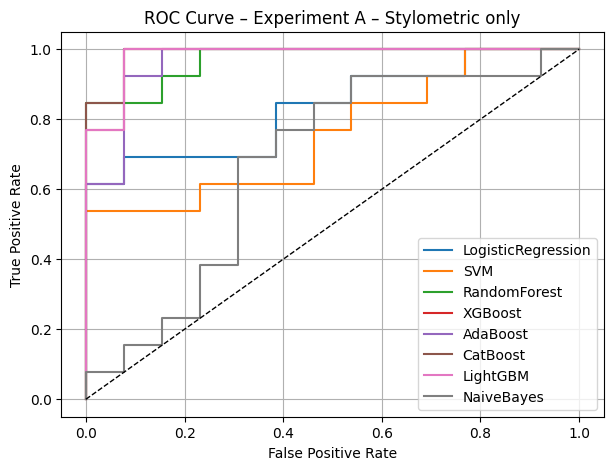

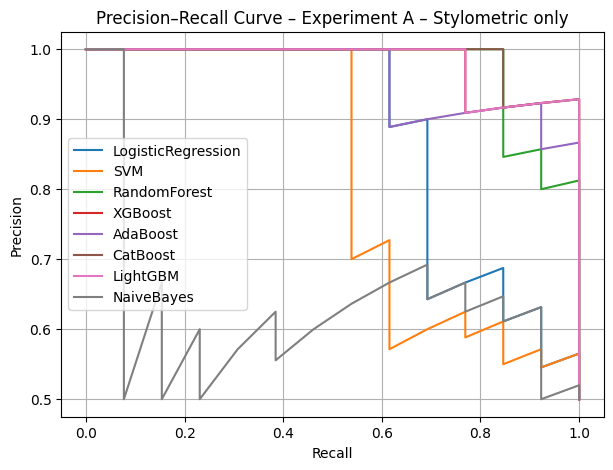

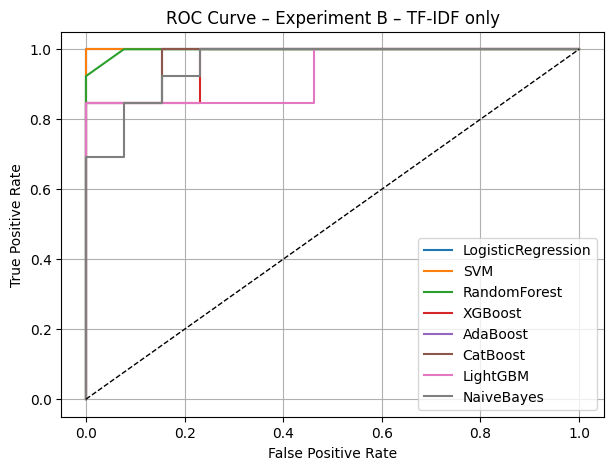

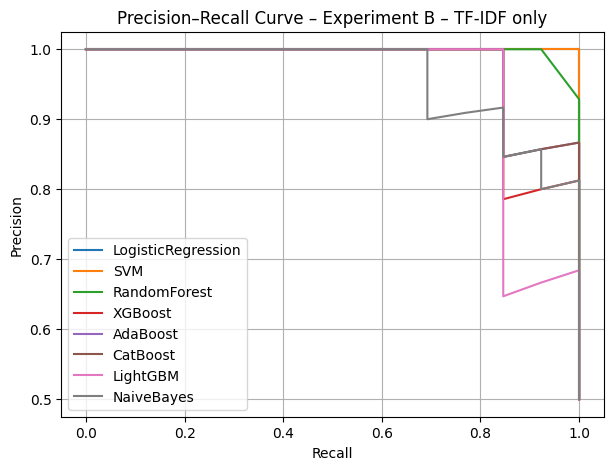

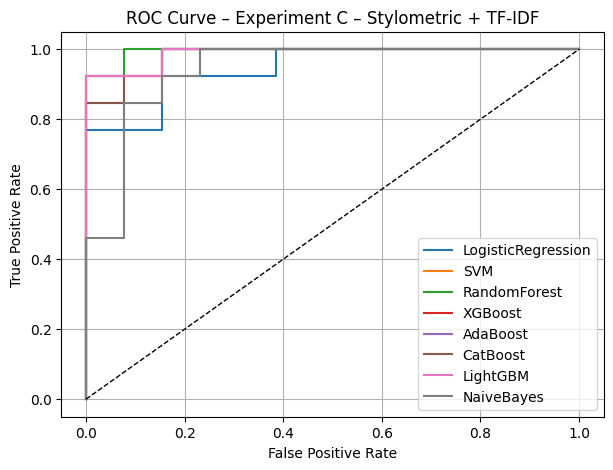

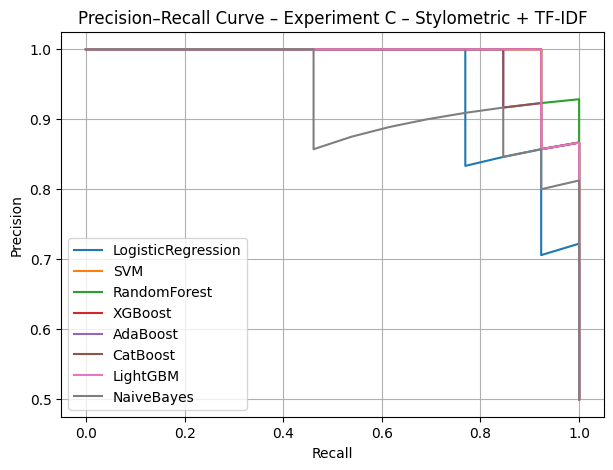


⭐ Best model for Experiment A – Stylometric only = AdaBoost (F1-test = 0.9231)


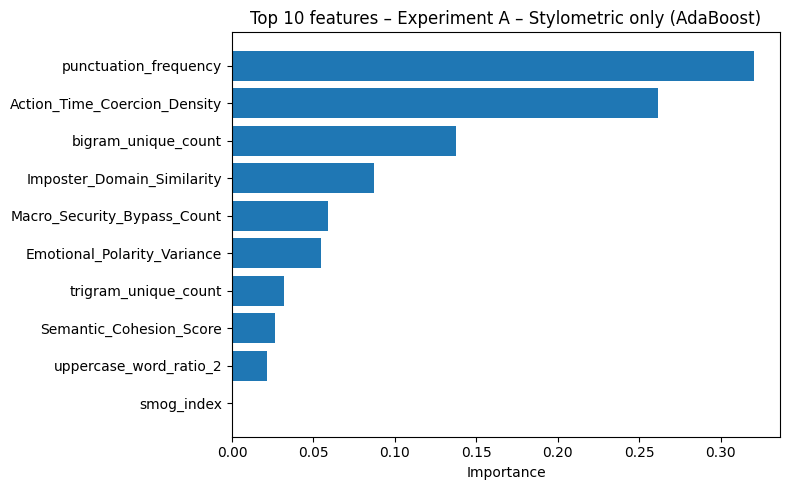


⭐ Best model for Experiment B – TF-IDF only = LogisticRegression (F1-test = 1.0000)


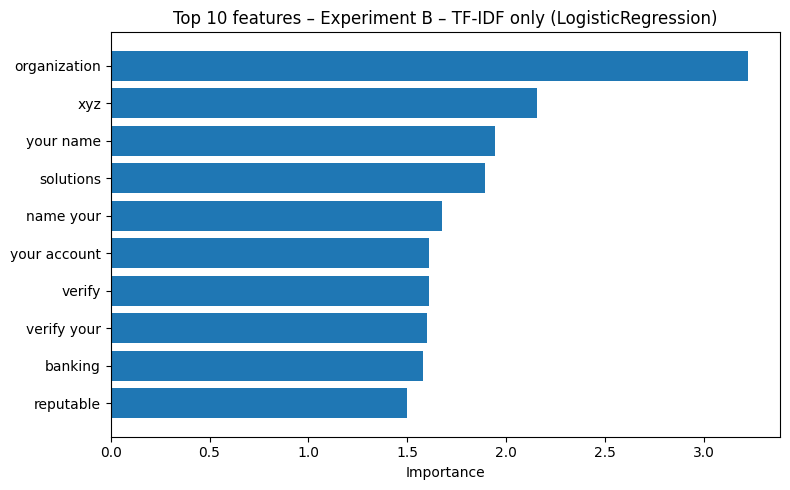


⭐ Best model for Experiment C – Stylometric + TF-IDF = RandomForest (F1-test = 0.9630)


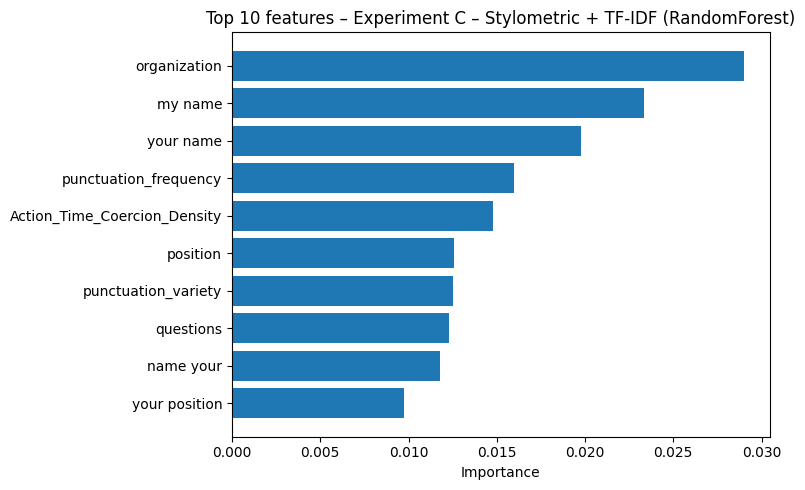


🏆 Global best model = LogisticRegression in Experiment B – TF-IDF only (F1-test = 1.0000)


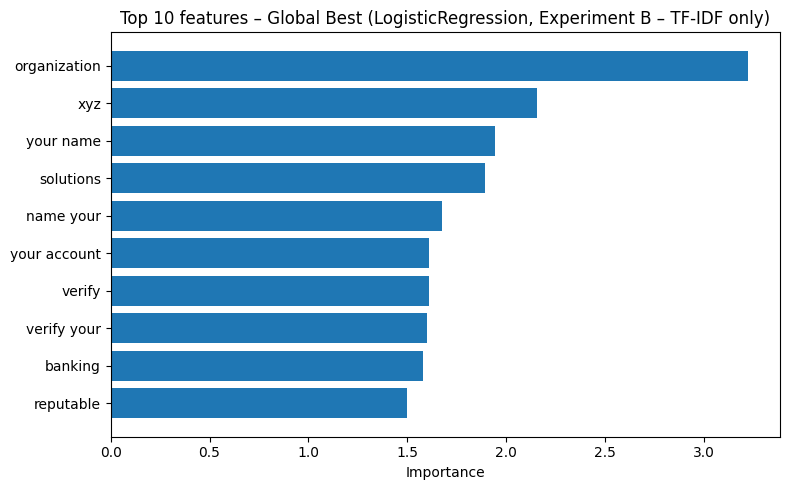

In [27]:
# ==========================================================
# Part 4 : Visualization + Run All Experiments
# ==========================================================

def plot_roc_and_pr_curves(experiment_result):
    name = experiment_result["name"]
    roc_pr = experiment_result["roc_pr"]

    # ROC Curve
    plt.figure(figsize=(7, 5))
    for model_name, data in roc_pr.items():
        fpr, tpr, _ = roc_curve(data["y_true"], data["y_score"])
        plt.plot(fpr, tpr, label=model_name)
    plt.plot([0, 1], [0, 1], "k--", linewidth=1)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve – {name}")
    plt.legend()
    plt.grid(True)
    plt.show()

    # PR Curve
    plt.figure(figsize=(7, 5))
    for model_name, data in roc_pr.items():
        precision, recall, _ = precision_recall_curve(
            data["y_true"], data["y_score"]
        )
        plt.plot(recall, precision, label=model_name)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision–Recall Curve – {name}")
    plt.legend()
    plt.grid(True)
    plt.show()


def get_feature_importances_generic(model, feature_names: List[str]):
    """
    คืน DataFrame feature_importance แบบ generic:
    - tree-based: ใช้ feature_importances_
    - linear: ใช้ |coef_|
    """
    if hasattr(model, "feature_importances_"):
        importances = np.array(model.feature_importances_)
    elif hasattr(model, "coef_"):
        coef = model.coef_
        if coef.ndim == 1:
            importances = np.abs(coef)
        else:
            importances = np.abs(coef).mean(axis=0)
    else:
        raise ValueError("Model ไม่มี attribute feature_importances_ หรือ coef_")

    imp_df = pd.DataFrame(
        {"feature": feature_names, "importance": importances}
    ).sort_values("importance", ascending=False)
    return imp_df


def plot_top_features(imp_df: pd.DataFrame, top_n: int, title: str):
    top = imp_df.head(top_n)[::-1]  # reverse เพื่อให้ bar ล่างสุดค่าเยอะสุด
    plt.figure(figsize=(8, 5))
    plt.barh(top["feature"], top["importance"])
    plt.title(title)
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()


def plot_top_features_for_best_models(
    exp_results: Dict[str, Dict],
    global_top_n: int = 10,
):
    """
    - หา best model (ตาม F1-score บน test) ของแต่ละ Experiment
    - หา best model รวมทุก Experiment
    - plot Horizontal bar chart Top N features
    """
    best_global = {
        "exp_key": None,
        "model_name": None,
        "f1": -1,
    }

    for key, res in exp_results.items():
        df_test = res["df_test"]
        models = res["models"]
        feature_names = res["feature_names"]

        best_row = df_test.iloc[0]  # เพราะ sort แล้ว F1-score จากมากไปน้อย
        best_model_name = best_row.name  # index = Index เดิม?   → ปรับใหม่:
        # จริง ๆ ใช้ column "Model" จะตรงสุด
        best_model_name = df_test.iloc[0]["Model"]
        best_f1 = float(df_test.iloc[0]["F1-score"])

        print(f"\n⭐ Best model for {res['name']} = {best_model_name} "
              f"(F1-test = {best_f1:.4f})")

        model = models[best_model_name]
        imp_df = get_feature_importances_generic(model, feature_names)
        plot_top_features(
            imp_df,
            global_top_n,
            title=f"Top {global_top_n} features – {res['name']} ({best_model_name})",
        )

        # update global best
        if best_f1 > best_global["f1"]:
            best_global.update(
                {"exp_key": key, "model_name": best_model_name, "f1": best_f1}
            )

    # Global best across all experiments
    g_key = best_global["exp_key"]
    g_model = best_global["model_name"]
    if g_key is not None:
        g_res = exp_results[g_key]
        g_model_obj = g_res["models"][g_model]
        g_feature_names = g_res["feature_names"]
        print(
            f"\n🏆 Global best model = {g_model} "
            f"in {g_res['name']} (F1-test = {best_global['f1']:.4f})"
        )
        g_imp_df = get_feature_importances_generic(g_model_obj, g_feature_names)
        plot_top_features(
            g_imp_df,
            global_top_n,
            title=f"Top {global_top_n} features – Global Best ({g_model}, {g_res['name']})",
        )


# ---------- Main Flow ----------
def main():
    # Step 0 : Load raw data
    train_df = load_email_csv("train.csv")
    test_df = load_email_csv("test.csv")
    print(f"Raw train shape: {train_df.shape}, test shape: {test_df.shape}")

    # Step 1 : Build stylometric features (60 features) → ได้ DataFrame ใหม่
    train_feat = build_feature_dataframe(train_df)
    test_feat = build_feature_dataframe(test_df)

    # Step 2 : สร้าง Design matrices ของแต่ละ Experiment
    XA_train, yA_train, XA_test, yA_test, feat_A = build_matrices_experiment_A(
        train_feat, test_feat
    )
    XB_train, yB_train, XB_test, yB_test, feat_B = build_matrices_experiment_B(
        train_feat, test_feat
    )
    XC_train, yC_train, XC_test, yC_test, feat_C = build_matrices_experiment_C(
        train_feat, test_feat
    )

    # Step 3 : Run Experiments A / B / C
    res_A = run_experiment(
        "Experiment A – Stylometric only",
        XA_train,
        yA_train,
        XA_test,
        yA_test,
        feat_A,
    )
    res_B = run_experiment(
        "Experiment B – TF-IDF only",
        XB_train,
        yB_train,
        XB_test,
        yB_test,
        feat_B,
    )
    res_C = run_experiment(
        "Experiment C – Stylometric + TF-IDF",
        XC_train,
        yC_train,
        XC_test,
        yC_test,
        feat_C,
    )

    # Step 4 : Plot ROC & PR curves
    plot_roc_and_pr_curves(res_A)
    plot_roc_and_pr_curves(res_B)
    plot_roc_and_pr_curves(res_C)

    # Step 5 : Top 10 feature importances (A, B, C + Global best)
    exp_results = {"A": res_A, "B": res_B, "C": res_C}
    plot_top_features_for_best_models(exp_results, global_top_n=10)


# สำหรับรันใน Colab cell สุดท้าย
main()
